# 03 — Deep Convolutional Network

Train a VGG-style `DeepConvNet` with the `Solver`, save it, reload from disk, and run inference on test images.

Unlike the linear / two-layer nets (which take flattened `(N, 3072)` vectors), a convnet keeps the spatial structure: inputs are images of shape `(N, 3, 32, 32)`. That's the only data difference — `preprocess_cifar10(flatten=False)`.

In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
%matplotlib inline
import random

import matplotlib.pyplot as plt
import torch

import dl
from dl.paths import REPO_ROOT
from dl.datasets import CLASSES
from dl.solver import Solver
from dl.optim import adam
from dl.models.convnet import DeepConvNet

# This is now a 5-layer net on the full 40k training set, so a GPU is strongly
# recommended (it is slow on CPU). Falls back to CPU automatically if none.
USE_CUDA = True
CUDA = USE_CUDA and torch.cuda.is_available()
print('device:', 'cuda' if CUDA else 'cpu')

device: cuda


In [7]:
dl.reset_seed(0)

# flatten=False keeps images as (N, 3, 32, 32) instead of (N, 3072).
data = dl.datasets.preprocess_cifar10(
    bias_trick=False,
    flatten=False,
    cuda=CUDA,
    dtype=torch.float32,
    show_examples=False,
)

for k in ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test']:
    print(f'{k:8s} {str(tuple(data[k].shape)):20s} {data[k].dtype}')

DTYPE, DEVICE = data['X_train'].dtype, data['X_train'].device

# Full training + validation set. Solver subsamples internally for its periodic
# accuracy checks (num_train_samples / num_val_samples), so passing all is fine.
small = {
    'X_train': data['X_train'], 'y_train': data['y_train'],
    'X_val':   data['X_val'],   'y_val':   data['y_val'],
}

CKPT_PATH = REPO_ROOT / 'checkpoints' / 'deep_convnet.pt'
CKPT_PATH.parent.mkdir(exist_ok=True)

X_train  (40000, 3, 32, 32)   torch.float32
y_train  (40000,)             torch.int64
X_val    (10000, 3, 32, 32)   torch.float32
y_val    (10000,)             torch.int64
X_test   (10000, 3, 32, 32)   torch.float32
y_test   (10000,)             torch.int64


## Train

Architecture: `{conv - batchnorm - relu - pool} x 5 - linear`, widening 32 → 256, with Kaiming init and Adam.

In [8]:
dl.reset_seed(0)

net = DeepConvNet(
    input_dims=(3, 32, 32),
    num_classes=10,
    num_filters=(32, 64, 128, 128, 256),   # 5 conv layers, widening with depth
    max_pools=(0, 1, 2, 3, 4),             # pool after each: 32 -> 16 -> 8 -> 4 -> 2 -> 1
    batchnorm=True,
    weight_init='kaiming',
    reg=1e-4,
    dtype=DTYPE,
    device=str(DEVICE),
)

solver = Solver(
    net, small,
    update_rule=adam,
    optim_config={'learning_rate': 1e-3},
    lr_decay=0.95,
    num_epochs=10,
    batch_size=128,
    print_every=500,
    device=str(DEVICE),
)
solver.train()

print(f'\nbest val accuracy: {solver.best_val_acc:.4f}')
print(f'test accuracy:     {solver.check_accuracy(data["X_test"], data["y_test"]):.4f}')
solver.model.save(str(CKPT_PATH))

(Time 0.02 sec; Iteration 1 / 3120) loss: 2.804515
(Epoch 0 / 10) train acc: 0.079000; val_acc: 0.102100
(Epoch 1 / 10) train acc: 0.658000; val_acc: 0.609300
(Time 11.14 sec; Iteration 501 / 3120) loss: 0.870763
(Epoch 2 / 10) train acc: 0.729000; val_acc: 0.672400
(Epoch 3 / 10) train acc: 0.807000; val_acc: 0.692600
(Time 20.58 sec; Iteration 1001 / 3120) loss: 0.653461
(Epoch 4 / 10) train acc: 0.796000; val_acc: 0.691600
(Time 29.78 sec; Iteration 1501 / 3120) loss: 0.433630
(Epoch 5 / 10) train acc: 0.862000; val_acc: 0.713500
(Epoch 6 / 10) train acc: 0.874000; val_acc: 0.710800
(Time 41.16 sec; Iteration 2001 / 3120) loss: 0.478457
(Epoch 7 / 10) train acc: 0.915000; val_acc: 0.736100
(Epoch 8 / 10) train acc: 0.957000; val_acc: 0.731500
(Time 50.14 sec; Iteration 2501 / 3120) loss: 0.222919
(Epoch 9 / 10) train acc: 0.943000; val_acc: 0.731000
(Time 60.73 sec; Iteration 3001 / 3120) loss: 0.198393
(Epoch 10 / 10) train acc: 0.943000; val_acc: 0.727900

best val accuracy: 0.736

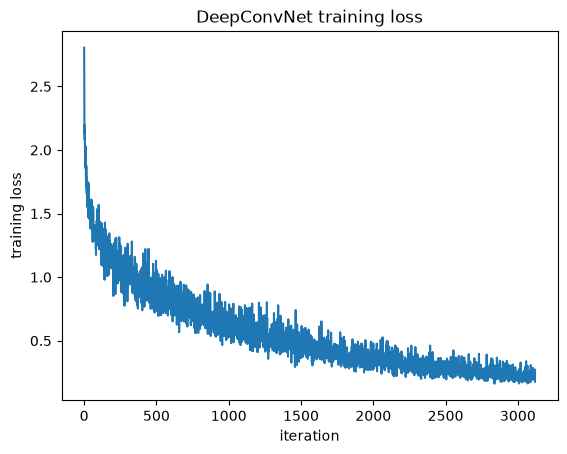

In [9]:
plt.plot(solver.loss_history)
plt.xlabel('iteration'); plt.ylabel('training loss'); plt.title('DeepConvNet training loss')
plt.show()

## Reload from checkpoint

Build a fresh net, load the trained weights from disk, and confirm the test accuracy matches.

In [10]:
fresh = DeepConvNet(
    input_dims=(3, 32, 32),
    num_classes=10,
    num_filters=(64,128,256,256,512,512,512,512),
    max_pools=(0, 1, 3, 5, 7),
    batchnorm=True,
    weight_init='kaiming',
    dtype=DTYPE,
    device=str(DEVICE),
)

fresh.load(str(CKPT_PATH), dtype=DTYPE, device=str(DEVICE))

# a throwaway Solver just to reuse its batched check_accuracy
evaluator = Solver(fresh, data, verbose=False, device=str(DEVICE))
print(f'reloaded test accuracy: {evaluator.check_accuracy(data["X_test"], data["y_test"]):.4f}')

reloaded test accuracy: 0.6669


## Predictions on test images

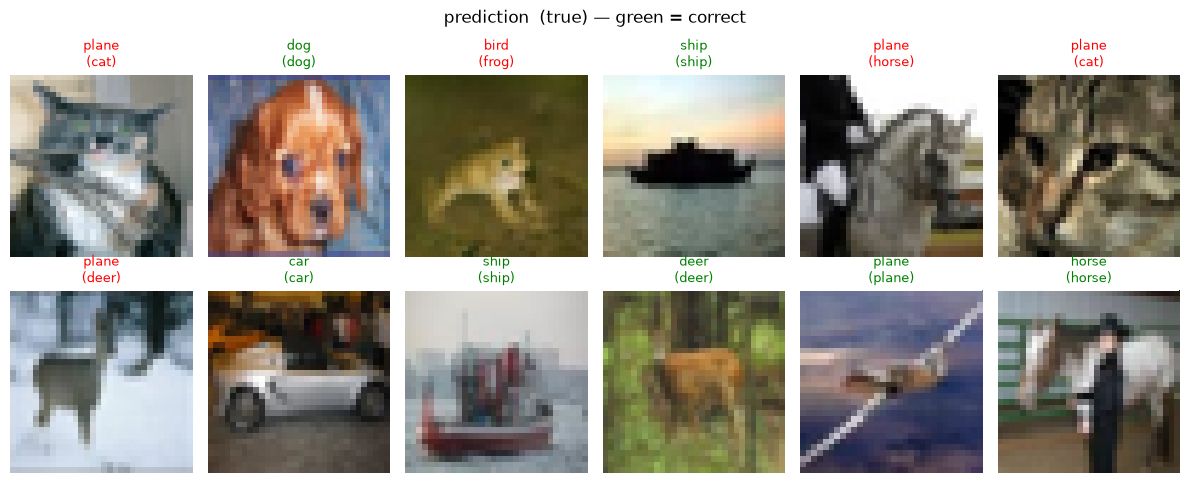

In [11]:
# Raw (un-normalized) images for display; cifar10() returns the test set in the
# same order as preprocess_cifar10(), so index i lines up between the two.
_, _, x_test_raw, _ = dl.datasets.cifar10(x_dtype=torch.float32)

dl.reset_seed(0)
idxs = random.sample(range(x_test_raw.shape[0]), 12)
preds = fresh.predict(data['X_test'][idxs])   # predict just the shown images

plt.figure(figsize=(12, 5))
for i, idx in enumerate(idxs):
    plt.subplot(2, 6, i + 1)
    plt.imshow(dl.tensor_to_image(x_test_raw[idx]))
    plt.axis('off')
    p, t = preds[i].item(), data['y_test'][idx].item()
    plt.title(f'{CLASSES[p]}\n({CLASSES[t]})',
              color='green' if p == t else 'red', fontsize=9)
plt.suptitle('prediction  (true) — green = correct')
plt.tight_layout()
plt.show()